# 1D Variance Preserving (VP) Ornstein-Uhlenbeck Score Matching

This notebook implements the Diffusion Denoising Score Matching framework for a 1D bimodal Gaussian distribution, matching exactly the optimization process outlined in `knowledge_base/score_matching.md`.

We track and evaluate the mathematical constraints of the network over the analytical score function, generating its reverse stationary distribution trajectories and histogram time evolution.

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import math

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Global Continuous OU Parameters
beta = 1.0  # Constant diffusion schedule parameter 
T = 1.0     # Max forward process distribution limit
t_eps = 1e-4

# Initial Dataset Parameters: Bimodal Gaussian Components
mu_1, sigma_1 = -2.0, 0.5
mu_2, sigma_2 = 2.0, 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute target: {device}")

Using compute target: cpu


## 1. Distribution Environment & Analytical Score
Defining the $p_0$ sampler corresponding exactly to the training distribution alongside the rigorously precise analytical $s(x,t)$ to benchmark our model conditionally across arbitrary timesteps.

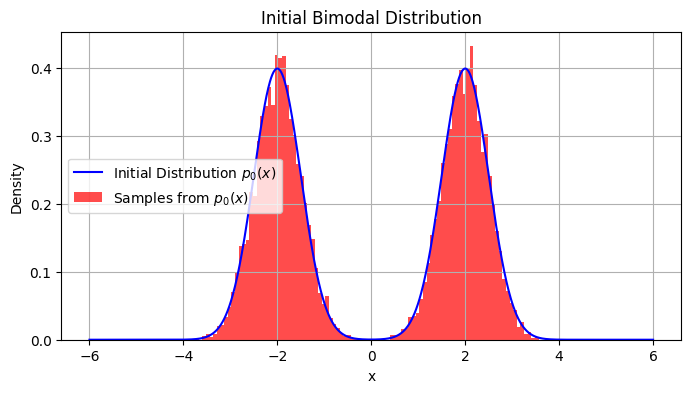

In [48]:
def sample_p0(batch_size):
    """Draw empirical batch conditions from original coordinates."""
    modes = torch.randint(0, 2, (batch_size, 1)).float().to(device)
    noise = torch.randn(batch_size, 1, device=device)
    samples_1 = mu_1 + sigma_1 * noise
    samples_2 = mu_2 + sigma_2 * noise
    return (1 - modes) * samples_1 + modes * samples_2
    
def get_p0_pdf(x_grid):
    """Yield true density for empirical plot visualizations."""
    p1 = np.exp(-0.5 * ((x_grid - mu_1)/sigma_1)**2) / (np.sqrt(2 * np.pi) * sigma_1)
    p2 = np.exp(-0.5 * ((x_grid - mu_2)/sigma_2)**2) / (np.sqrt(2 * np.pi) * sigma_2)
    return 0.5 * p1 + 0.5 * p2

def analytical_score(x, t):
    """
    Computes numerically stable, conditionally exact components substituting marginal Gaussian metrics.
    """
    alpha_t = torch.exp(-0.5 * beta * t)
    var_t = 1.0 - torch.exp(-beta * t)
    
    m1_t = alpha_t * mu_1
    S1_t = (alpha_t**2) * (sigma_1**2) + var_t
    
    m2_t = alpha_t * mu_2
    S2_t = (alpha_t**2) * (sigma_2**2) + var_t
    
    # Scale log PDFs to eliminate division underflows over time bounds
    log_p1 = -0.5 * math.log(2 * math.pi) - 0.5 * torch.log(S1_t) - 0.5 * ((x - m1_t)**2) / S1_t
    log_p2 = -0.5 * math.log(2 * math.pi) - 0.5 * torch.log(S2_t) - 0.5 * ((x - m2_t)**2) / S2_t
    
    log_p_stack = torch.stack([log_p1, log_p2], dim=-1)
    weights = torch.softmax(log_p_stack, dim=-1)
    
    w1, w2 = weights[..., 0], weights[..., 1]
    
    # Conditional combinations mapped to scores
    score1 = -(x - m1_t) / S1_t
    score2 = -(x - m2_t) / S2_t
    
    return w1 * score1 + w2 * score2

#plotting the initial distribution and the samples drawn from it
x_grid = np.linspace(-6, 6, 1000)
pdf_values = get_p0_pdf(x_grid)
samples = sample_p0(10000).cpu().numpy()
plt.figure(figsize=(8, 4))
plt.plot(x_grid, pdf_values, label='Initial Distribution $p_0(x)$',
            color='blue')
plt.hist(samples, bins=100, density=True, alpha=0.7, label='Samples from $p_0(x)$', color='red')
plt.title('Initial Bimodal Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()


## 2. Model Structure & Training Loop
Implementing the neural approximation matching strictly back to the Weighted $\mathcal{L}(\theta)$ gradient objective: 
$\mathcal{L}(\theta) = \sigma_t^2 \left\| s_\theta(x_t, t) + \frac{\epsilon}{\sigma_t} \right\|_2^2$ 
which simplifies into preserving unit variance via $\|\sigma_t s_\theta(x_t,t) + \epsilon\|_2^2$.

In [49]:
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 24), nn.ReLU(),
            nn.Linear(24, 12), nn.ReLU(),
            nn.Linear(12, 1)
        )
        
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=-1))

model = ScoreNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

iterations = 6000
batch_size = 1000
loss_history = []

model.train()
for i in range(iterations):
    optimizer.zero_grad()
    
    # 1. Sample arbitrary times across distributions
    t = torch.rand(batch_size, 1, device=device) * (T - t_eps) + t_eps
    # 2. Extract batch starting conditions
    x_0 = sample_p0(batch_size)
    # 3. Pull random variable epsilon condition
    epsilon = torch.randn_like(x_0)
    
    # 4. Integrate determinism over variance limits
    alpha_t = torch.exp(-0.5 * beta * t)
    sigma_t = torch.sqrt(1.0 - torch.exp(-beta * t))
    
    # Apply precise variable scaling 
    x_t = alpha_t * x_0 + sigma_t * epsilon
    
    # 5. Evaluate substitute target map functions
    score_pred = model(x_t, t)
    
    # 6. Apply identical equivalent reduction to weighted objective:
    loss = torch.mean((sigma_t * score_pred + epsilon) ** 2)
    
    # 7. Update parameters
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if (i + 1) % 1000 == 0:
        print(f"Iteration {i+1:04d}/{iterations} | Average Objective: {np.mean(loss_history[-1000:]):.5f}")

Iteration 1000/6000 | Average Objective: 0.62944
Iteration 2000/6000 | Average Objective: 0.55271
Iteration 3000/6000 | Average Objective: 0.54644
Iteration 4000/6000 | Average Objective: 0.53984
Iteration 5000/6000 | Average Objective: 0.53980
Iteration 6000/6000 | Average Objective: 0.53971


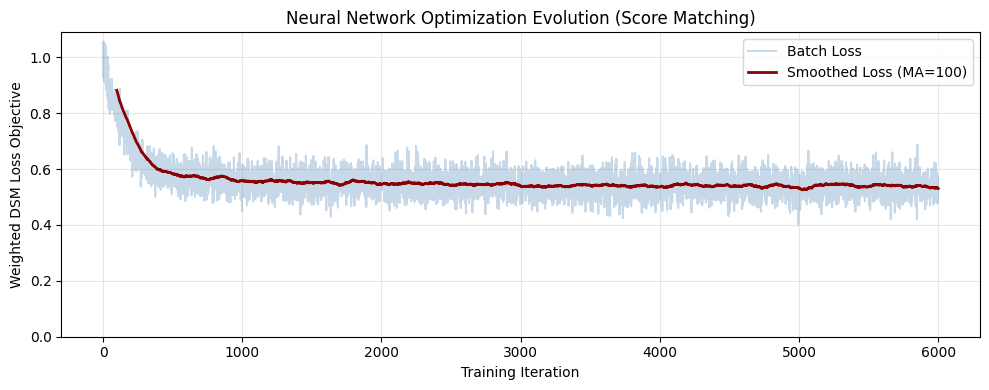

In [50]:
# Plot the loss evolution to verify convergence
plt.figure(figsize=(10, 4))
plt.plot(loss_history, alpha=0.3, label="Batch Loss", color="steelblue")

# Computing a moving average for a smoother underlying trend visualization 
window = 100
smoothed_loss = np.convolve(loss_history, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(loss_history)), smoothed_loss, color="darkred", lw=2, label=f"Smoothed Loss (MA={window})")

plt.xlabel("Training Iteration")
plt.ylabel("Weighted DSM Loss Objective")
plt.title("Neural Network Optimization Evolution (Score Matching)")
plt.ylim(bottom=0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. The Reverse SDE Sampler (Langevin Dynamics)
Simulating $dx = \left[\frac{1}{2}\beta x - \beta s_\theta(x, t)\right]dt + \sqrt{\beta}d\bar{W}$ continuously backward incrementally.

In [51]:
def reverse_sampler(target_score_fn, n_samples=2000, n_steps=500, return_trajectories=False):
    dt = T / n_steps
    # Start pure normal limit (t=T)
    x = torch.randn(n_samples, 1, device=device)
    trajectories = [x.clone().cpu().numpy()]
    
    for i in range(n_steps):
        t_cur = T - i * dt
        t_tensor = torch.full_like(x, float(t_cur), device=device)
        
        with torch.no_grad():
            score = target_score_fn(x, t_tensor)
            
        # Reverse SDE equation substituting dx backwards
        f_x = -0.5 * beta * x
        g2 = beta
        drift = f_x - g2 * score
        noise = torch.randn_like(x) if i < n_steps - 1 else torch.zeros_like(x)
        
        # Applying discretized backward step (effectively -dt)
        x = x - drift * dt + math.sqrt(beta * dt) * noise
        
        if return_trajectories:
            trajectories.append(x.clone().cpu().numpy())
            
    return trajectories if return_trajectories else x.cpu()

## Task 1: Empirical vs Theoretical Output (Stationary Distribution)
Verifying how correctly approximations align against analytical targets.

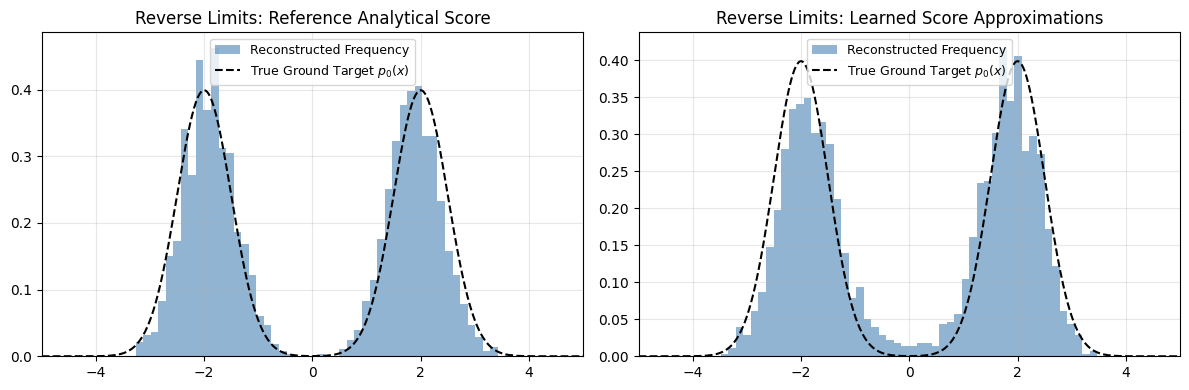

In [52]:
model.eval()
final_ana = reverse_sampler(analytical_score)
final_nn = reverse_sampler(model)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
x_grid = np.linspace(-5, 5, 800)
p0_vals = get_p0_pdf(x_grid)

for ax, target_samples, title in zip([ax1, ax2], [final_ana, final_nn], ["Reference Analytical Score", "Learned Score Approximations"]):
    ax.hist(target_samples.numpy(), bins=50, density=True, alpha=0.6, color='steelblue', label='Reconstructed Frequency')
    ax.plot(x_grid, p0_vals, 'k--', label='True Ground Target $p_0(x)$')
    
    ax.set_xlim(-5, 5)
    ax.set_title(f"Reverse Limits: {title}")
    ax.legend(loc="upper center", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 2: Sampling Trajectories
Visualizing pathing convergences independently reversing out into clustered modalities.

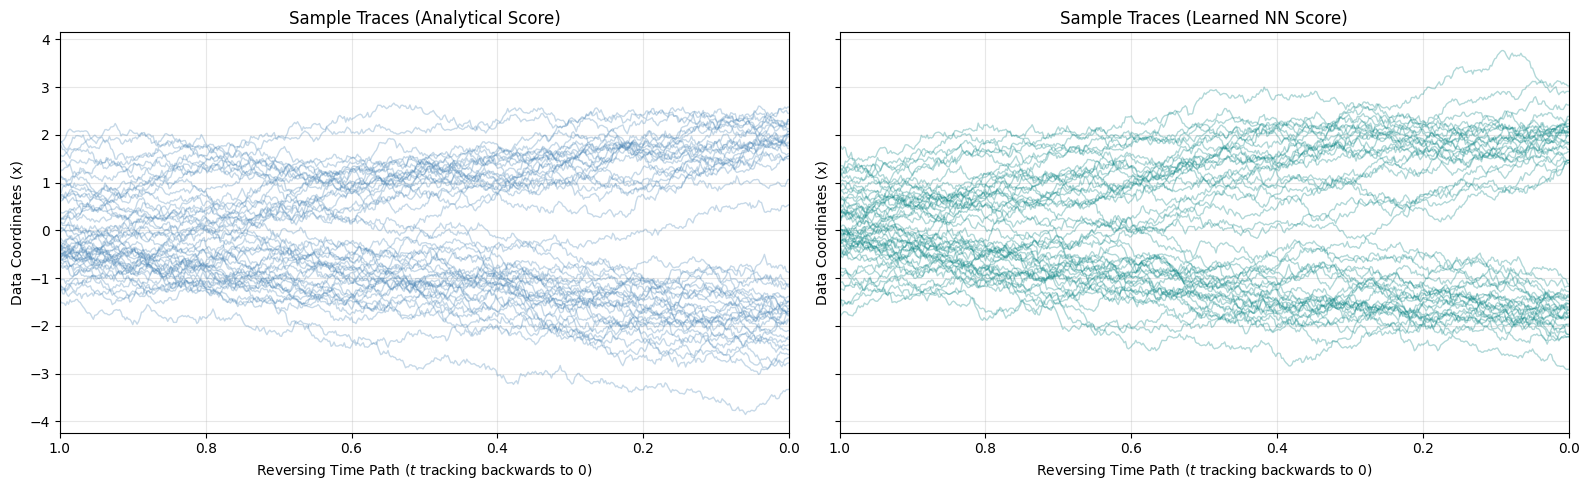

In [53]:
nn_sample_traject = reverse_sampler(model, n_samples=50, n_steps=500, return_trajectories=True)
nn_sample_traject = np.stack(nn_sample_traject, axis=1).squeeze(-1) 

ana_sample_traject = reverse_sampler(analytical_score, n_samples=50, n_steps=500, return_trajectories=True)
ana_sample_traject = np.stack(ana_sample_traject, axis=1).squeeze(-1) 

time_steps_range = np.linspace(T, 0, 501)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for i in range(50):
    ax1.plot(time_steps_range, ana_sample_traject[i], color='steelblue', alpha=0.3, lw=1)
    ax2.plot(time_steps_range, nn_sample_traject[i], color='teal', alpha=0.3, lw=1)

for ax, title in zip([ax1, ax2], ["Sample Traces (Analytical Score)", "Sample Traces (Learned NN Score)"]):
    ax.set_xlim(T, 0)
    ax.set_title(title)
    ax.set_xlabel("Reversing Time Path ($t$ tracking backwards to $0$)")
    ax.set_ylabel("Data Coordinates (x)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Task 3: Histogram Time Evolution
Checking distributional configurations systematically across bounds as probability pulls backward down the continuous sequence.

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_95469/3123049755.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_grid, prior_pdf, 'r--', label="$\mathcal{N}(0, I)$ Prior")


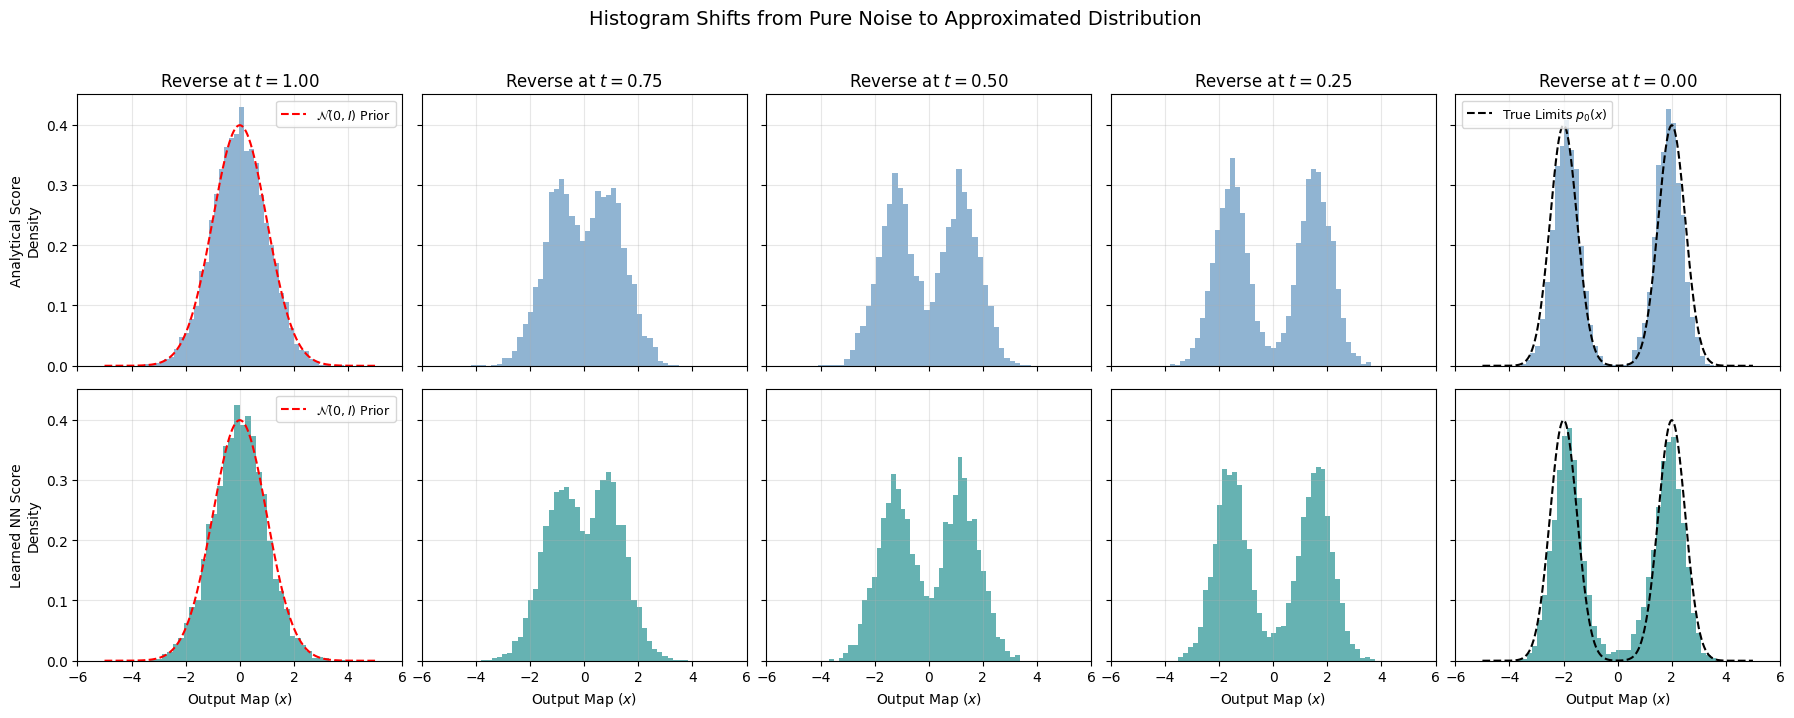

In [54]:
full_temporal_trajs_nn = reverse_sampler(model, n_samples=5000, n_steps=500, return_trajectories=True)
full_temporal_trajs_nn = np.stack(full_temporal_trajs_nn, axis=1).squeeze(-1)

full_temporal_trajs_ana = reverse_sampler(analytical_score, n_samples=5000, n_steps=500, return_trajectories=True)
full_temporal_trajs_ana = np.stack(full_temporal_trajs_ana, axis=1).squeeze(-1)

recorded_milestones = [0, 125, 250, 375, 500] 
fig, axes = plt.subplots(2, len(recorded_milestones), figsize=(18, 7), sharey=True, sharex=True)

for row, (trajs, color, label) in enumerate(zip(
    [full_temporal_trajs_ana, full_temporal_trajs_nn], 
    ['steelblue', 'teal'], 
    ['Analytical Score', 'Learned NN Score']
)):
    for i, iter_step in enumerate(recorded_milestones):
        t_val = T - iter_step * (T / 500)
        ax = axes[row, i]
        
        ax.hist(trajs[:, iter_step], bins=40, density=True, alpha=0.6, color=color)
        
        if iter_step == 500:
            ax.plot(x_grid, get_p0_pdf(x_grid), 'k--', label="True Limits $p_0(x)$")
            if i == 0 or row == 0: ax.legend(fontsize=9)
        elif iter_step == 0:
            prior_pdf = np.exp(-0.5 * x_grid**2) / np.sqrt(2 * np.pi)
            ax.plot(x_grid, prior_pdf, 'r--', label="$\mathcal{N}(0, I)$ Prior")
            if i == 0 or row == 0: ax.legend(fontsize=9)
            
        if row == 0:
            ax.set_title(f"Reverse at $t = {t_val:.2f}$")
        if i == 0:
            ax.set_ylabel(f"{label}\nDensity")
        if row == 1:
            ax.set_xlabel("Output Map ($x$)")
            
        ax.grid(alpha=0.3)
        ax.set_xlim(-6, 6)

plt.suptitle("Histogram Shifts from Pure Noise to Approximated Distribution", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Task 4: Score Function Field Comparison
Visually confirming the fidelity of the trained network by overlaying its conditional score outputs $s_\theta(x, t)$ directly over the true analytical marginal scores $\nabla_x\log p_t(x)$ across an array of temporal diffusion depths.

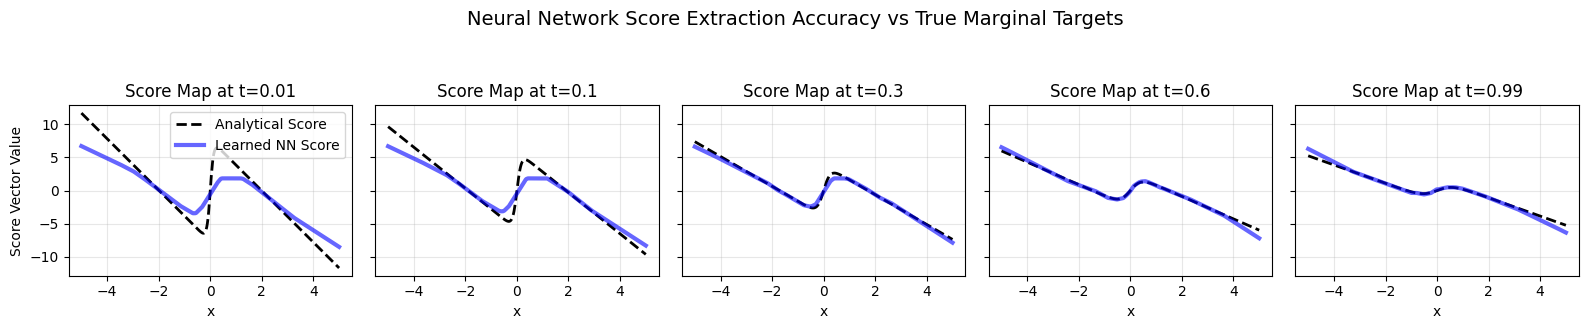

In [55]:
# Evaluate the score functions physically across a specific spatial grid and timesteps
model.eval()
evaluate_times = [0.01, 0.1, 0.3, 0.6, 0.99]
x_vals = torch.linspace(-5, 5, 400).unsqueeze(1).to(device)

fig, axes = plt.subplots(1, len(evaluate_times), figsize=(16, 3), sharex=True, sharey=True)

with torch.no_grad():
    for idx, t_val in enumerate(evaluate_times):
        t_tensor = torch.full_like(x_vals, t_val)
        nn_score = model(x_vals, t_tensor)
        true_score = analytical_score(x_vals, t_tensor)
        
        ax = axes[idx]
        ax.plot(x_vals.cpu().numpy(), true_score.cpu().numpy(), 'k--', lw=2, label="Analytical Score")
        ax.plot(x_vals.cpu().numpy(), nn_score.cpu().numpy(), 'b-', alpha=0.6, lw=3, label="Learned NN Score")
        
        ax.set_title(f"Score Map at t={t_val}")
        ax.set_xlabel("x")
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.set_ylabel("Score Vector Value")
            ax.legend()

plt.suptitle("Neural Network Score Extraction Accuracy vs True Marginal Targets", y=1.08, fontsize=14)
plt.tight_layout()
plt.show()